# ***THEORY ANSWERS***

Question 1: What is the fundamental idea behind ensemble techniques? How does bagging differ from boosting in terms of approach and objective?

Answer:
The fundamental idea behind ensemble techniques is that combining the predictions of multiple "weak" or moderately accurate models produces a final prediction that is more accurate and stable than any single model alone. By aggregating diverse models, errors specific to one model tend to cancel out, while the common, correct signal reinforces itself — reducing both variance and, in some approaches, bias.

Bagging (Bootstrap Aggregating):

Trains multiple models (usually of the same type, e.g. decision trees) independently and in parallel.
Each model is trained on a different bootstrap sample (random sample with replacement) of the training data.
Final prediction is obtained by averaging (regression) or majority voting (classification).
Primary objective: reduce variance and prevent overfitting. Works best with high-variance, low-bias base learners (e.g. deep decision trees).
Example: Random Forest.

Boosting:

Trains models sequentially, where each new model focuses on correcting the errors (misclassified/high-residual samples) of the previous ones.
Samples predicted incorrectly are given higher weight (AdaBoost), or the next model is fit on the residual errors (Gradient Boosting).
Final prediction is a weighted combination of all models.
Primary objective: reduce bias (and variance to some extent) by iteratively improving a weak learner into a strong one.
Example: AdaBoost, Gradient Boosting, XGBoost, CatBoost.

Key difference in one line: Bagging builds independent models in parallel to reduce variance; boosting builds dependent models sequentially, each correcting the previous one's mistakes, to reduce bias.

Question 2: Explain how the Random Forest Classifier reduces overfitting compared to a single decision tree. Mention the role of two key hyperparameters in this process.

Answer:
A single decision tree, if grown fully, tends to memorize the training data — capturing noise along with the signal, resulting in low bias but high variance (overfitting). Random Forest reduces overfitting through two forms of randomness combined with aggregation:

Bagging (row sampling): Each tree is trained on a different bootstrap sample of the data. Because each tree sees a slightly different dataset, individual trees overfit to different noise patterns. Averaging/voting across many such trees cancels out this noise, reducing overall variance.
Feature randomness (column sampling): At each split, only a random subset of features is considered (rather than all features). This de-correlates the trees — otherwise most trees would keep splitting on the same dominant feature and end up highly correlated, limiting the variance-reduction benefit of averaging.

Role of two key hyperparameters:

n_estimators (number of trees): More trees generally reduce variance further and stabilize predictions, since averaging many independent estimators has lower variance than a few. Beyond a point, adding trees gives diminishing returns but doesn't increase overfitting.
max_features (features considered per split): Controls how de-correlated the trees are. A smaller value increases randomness/diversity among trees (lower variance, slightly higher bias per tree); a larger value makes trees more similar to a single decision tree, increasing correlation and reducing the variance-reduction benefit.

Question 3: What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case.

Answer:
Stacking (Stacked Generalization) is an ensemble technique that combines predictions from multiple different base models (level-0 models, e.g. KNN, SVM, Decision Tree, Logistic Regression) by training a separate meta-model (level-1 model) that learns how to best combine their outputs into a final prediction.

Process:

Train several diverse base models on the training data (often using cross-validation to generate out-of-fold predictions, avoiding data leakage).
Use the base models' predictions as new input features.
Train a meta-learner (commonly a simple model like logistic/linear regression) on these predictions to produce the final output.

How it differs from bagging/boosting:

Bagging and boosting typically use the same type of base learner repeatedly (homogeneous ensembles); stacking typically combines different types of models (heterogeneous ensemble).
Bagging trains models independently/in parallel; boosting trains models sequentially with re-weighting; stacking explicitly learns a combination function via a meta-model, rather than simple voting/averaging.
Stacking can capture more complex relationships between base-model outputs, since the meta-model can learn which base model to "trust" in which situations.

Example use case: In a Kaggle competition, one might stack a Random Forest, a Gradient Boosting model, and a KNN classifier — each captures different patterns in the data — and use Logistic Regression as the meta-model to combine their probability outputs into a final, more accurate prediction.

Question 4: What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?

Answer:
Out-of-Bag (OOB) Score is a validation technique built into Random Forest (and other bagging methods) that estimates model performance without needing a separate held-out validation set.

How it works: Each tree is trained on a bootstrap sample drawn with replacement from the training data. On average, each bootstrap sample contains only about 63% of the unique original data points; the remaining ~37% are left out of that tree's training — these are the "out-of-bag" samples for that tree.

For every training data point, Random Forest identifies all trees for which that point was OOB.
Those trees predict the label for that point, and predictions are aggregated (majority vote/average) to get an OOB prediction.
Comparing OOB predictions to true labels across all training points gives the OOB score.

Why it's useful:

Provides an unbiased estimate of generalization performance using only the training data, since predictions come from trees that never saw that sample — like built-in cross-validation.
Saves data: no need for a separate validation split, valuable with smaller datasets.
Computationally efficient — reuses already-trained trees.
In scikit-learn, oob_score=True computes this automatically, exposed via .oob_score_.

Question 5: Compare AdaBoost and Gradient Boosting in terms of: how they handle errors, weight adjustment mechanism, typical use cases.

Answer:

Aspect	AdaBoost	Gradient Boosting
Handling errors from weak learners	Focuses on misclassified samples by increasing their weights so the next weak learner (often a decision stump) pays more attention to them.	Focuses on residual errors (difference between actual and predicted) of the previous model; the next learner is fit to predict these residuals directly.
Weight adjustment mechanism	Adjusts sample weights after each round — misclassified samples get higher weights. Each weak learner gets a weight (alpha) based on accuracy, used in the final weighted vote.	Does not reweight samples. Fits each new tree to the negative gradient (residual) of a loss function — gradient descent in function space.
Typical use cases	Works well on cleaner datasets; sensitive to outliers/noisy labels. Used in face detection, simpler binary classification.	More flexible — supports multiple loss functions, more robust via learning rate/shrinkage; basis of XGBoost, LightGBM, CatBoost. Used widely in tabular data competitions, CTR prediction, risk scoring.

In short: AdaBoost re-weights data points and combines weak learners via a weighted vote; Gradient Boosting fits successive learners to residual errors using gradient descent on a loss function, offering more flexibility and generally stronger performance on complex tabular problems.

Question 6: Why does CatBoost perform well on categorical features without requiring extensive preprocessing?

Answer:
Most gradient boosting implementations require categorical variables to be manually preprocessed (one-hot/label/target encoding) before training, risking high dimensionality, information loss, or target leakage. CatBoost handles categorical features natively:

Ordered Target Statistics: Instead of naive target encoding (which can leak target info and overfit), CatBoost computes target statistics for a categorical value using only data appearing before the current sample in a random permutation — mimicking online learning and preventing leakage.
Automatic feature combinations: CatBoost can automatically combine categorical features (e.g. "city" + "day of week") that hold additional predictive signal, which normally requires manual engineering.
Ordered Boosting: Uses ordering not just for encoding but for the boosting procedure itself, further reducing prediction shift/overfitting.
Efficient high-cardinality handling: Avoids the sparse, high-dimensional explosion caused by one-hot encoding.

# **PRACTICAL ANSWER**

Question 7: KNN Classifier — Wine Dataset Analysis with Optimization

Answer / Code:

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Without scaling
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print("Accuracy (no scaling):", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
knn_s = KNeighborsClassifier(n_neighbors=5)
knn_s.fit(X_train_s, y_train)
pred_s = knn_s.predict(X_test_s)
print("Accuracy (scaled):", accuracy_score(y_test, pred_s))
print(classification_report(y_test, pred_s))

# GridSearchCV
param_grid = {'n_neighbors': list(range(1,21)), 'metric': ['euclidean','manhattan']}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_s, y_train)
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_knn = grid.best_estimator_
pred_best = best_knn.predict(X_test_s)
print("Optimized Accuracy:", accuracy_score(y_test, pred_best))
print(classification_report(y_test, pred_best))

Accuracy (no scaling): 0.7407407407407407
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.75      0.71      0.73        21
           2       0.53      0.57      0.55        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.74      0.74      0.74        54

Accuracy (scaled): 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54

Best Params: {'metric': 'manhattan', 'n_neighbors': 1}
Best CV Score: 0.9753333333333334
Optimized Accuracy: 0.9629629629629629
              precision    rec

Question 8: PCA + KNN with Variance Analysis and Visualization

Answer / Code:

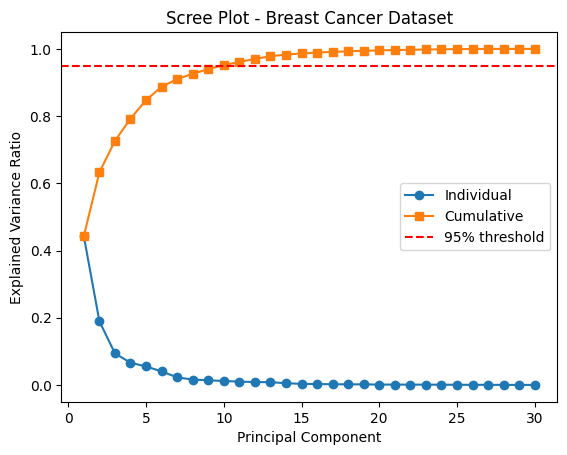

Components for 95% variance: 10
Accuracy (original scaled): 0.9590643274853801
Accuracy (PCA-transformed): 0.9649122807017544


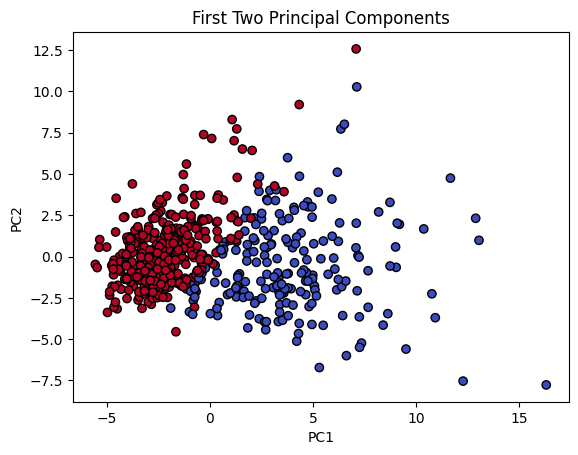

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.plot(range(1,len(explained)+1), explained, 'o-', label='Individual')
plt.plot(range(1,len(cum_explained)+1), cum_explained, 's-', label='Cumulative')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component'); plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Breast Cancer Dataset'); plt.legend(); plt.show()

pca_95 = PCA(n_components=0.95)
X_pca = pca_95.fit_transform(X_scaled)
print("Components for 95% variance:", pca_95.n_components_)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.3, random_state=42)

knn_orig = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print("Accuracy (original scaled):", accuracy_score(y_test, knn_orig.predict(X_test)))

knn_pca = KNeighborsClassifier(n_neighbors=5).fit(X_train_pca, y_train)
print("Accuracy (PCA-transformed):", accuracy_score(y_test, knn_pca.predict(X_test_pca)))

# scatter of first 2 PCs
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('First Two Principal Components')
plt.show()

Question 9: KNN Regressor with Distance Metrics and K-Value Analysis

Answer

MSE Euclidean: 4803.90558674207
MSE Manhattan: 5210.225816542467
K=1, MSE=8430.42
K=5, MSE=4803.91
K=10, MSE=5041.11
K=20, MSE=5712.02
K=50, MSE=8251.37


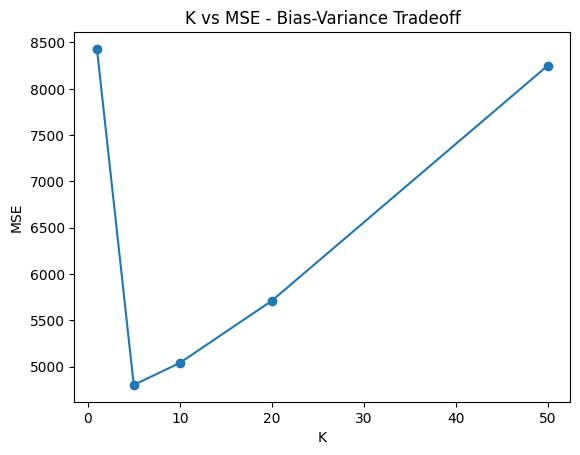

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=500, n_features=10, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn_euc = KNeighborsRegressor(n_neighbors=5, metric='euclidean').fit(X_train, y_train)
mse_euc = mean_squared_error(y_test, knn_euc.predict(X_test))

knn_man = KNeighborsRegressor(n_neighbors=5, metric='manhattan').fit(X_train, y_train)
mse_man = mean_squared_error(y_test, knn_man.predict(X_test))

print("MSE Euclidean:", mse_euc)
print("MSE Manhattan:", mse_man)

k_values = [1,5,10,20,50]
mse_list = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    mse = mean_squared_error(y_test, knn.predict(X_test))
    mse_list.append(mse)
    print(f"K={k}, MSE={mse:.2f}")

plt.plot(k_values, mse_list, 'o-')
plt.xlabel('K'); plt.ylabel('MSE'); plt.title('K vs MSE - Bias-Variance Tradeoff')
plt.show()

Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World Data.

Answer / Code:

Shape: (768, 9)
Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

Missing values per column:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
brute      -> time: 0.00962s | accuracy: 0.7359
kd_tree    -> time: 0.01892s | accuracy: 0.7359
ball_tree  -> time: 0.01378s | accuracy: 0.7359

Best performing method: brute


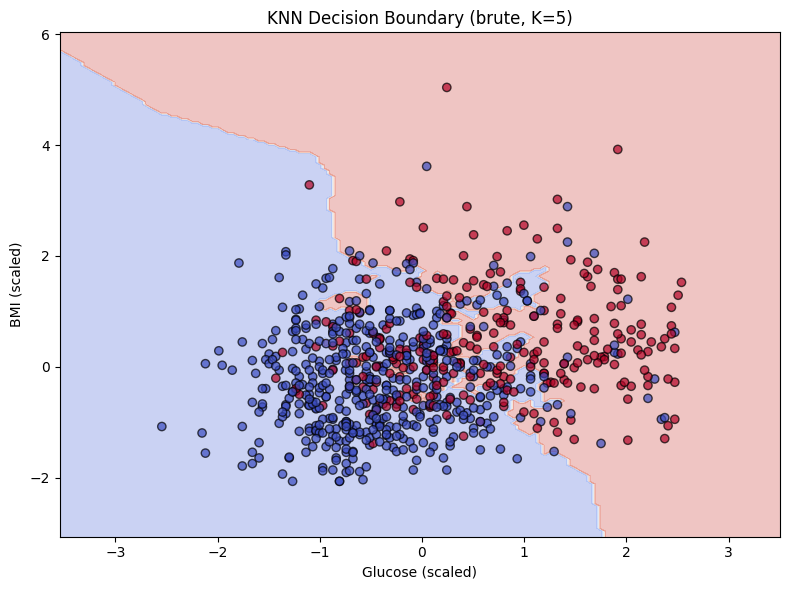

In [7]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load the Pima Indians Diabetes dataset
# -----------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, names=columns)
df = df.reset_index(drop=True)

print("Shape:", df.shape)
print("Outcome distribution:\n", df['Outcome'].value_counts())

# -----------------------------
# 2. Handle missing values (0 = missing in these columns)
# -----------------------------
cols_with_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)
print("\nMissing values per column:\n", df[cols_with_missing].isna().sum())

# -----------------------------
# 3. Separate features/target, then KNN-impute
# -----------------------------
X_raw = df.drop(columns='Outcome')
y = df['Outcome'].reset_index(drop=True)

imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_raw)
X = pd.DataFrame(X_imputed, columns=X_raw.columns)

# -----------------------------
# 4. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 5. Train-test split (stratified, keeps class balance)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 6. Train KNN with Brute-force, KD-Tree, Ball-Tree and compare
# -----------------------------
results = {}
for algo in ['brute', 'kd_tree', 'ball_tree']:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    start = time.time()
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, pred)
    results[algo] = (elapsed, acc)
    print(f"{algo:10s} -> time: {elapsed:.5f}s | accuracy: {acc:.4f}")

best_algo = max(results, key=lambda a: results[a][1])
print("\nBest performing method:", best_algo)

# -----------------------------
# 7. Decision boundary using 2 most important features (Glucose, BMI)
# -----------------------------
feat1, feat2 = 'Glucose', 'BMI'
X2 = X[[feat1, feat2]].values
X2_scaled = StandardScaler().fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y, test_size=0.3, random_state=42, stratify=y
)

knn2 = KNeighborsClassifier(n_neighbors=5, algorithm=best_algo)
knn2.fit(X2_train, y2_train)

x_min, x_max = X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1
y_min, y_max = X2_scaled[:, 1].min() - 1, X2_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                      np.arange(y_min, y_max, 0.05))
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=y, cmap='coolwarm',
            edgecolor='k', alpha=0.7)
plt.xlabel('Glucose (scaled)')
plt.ylabel('BMI (scaled)')
plt.title(f'KNN Decision Boundary ({best_algo}, K=5)')
plt.tight_layout()
plt.savefig('q10_decision_boundary.png', dpi=120)
plt.show()